In [1]:
%matplotlib inline

from cmcrameri import cm
from skimage import filters
from skimage.feature import peak_local_max
from skimage import measure
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.signal import find_peaks, peak_prominences
from scipy.spatial import cKDTree
from scipy import ndimage as ndi
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from skimage.segmentation import watershed
from tslearn.clustering import KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
import matplotlib.colorizer as mpl
import networkx as nx
import matplotlib.pyplot as plt
import h5py
import numpy as np
import pandas as pd

In [2]:
# Specify timeseries files
StorePath = '/work/xfc/vol7/user_cache/benirela/Other/Pedro_TS/'
EndPath = 'Wolf/106A/TS_GEOCml2clipmask/cum_filt.h5'
TS_File = StorePath + EndPath
#TS_File = StorePath + 'Dabbahu/014A/TS_GEOCml2clipmask/cum_filt.h5'

# Open timeseries file
with h5py.File(TS_File, "r") as f:
    ImDates = f["/imdates"][:]
    LOS = f["/cum"][:]
    cLat = f["/corner_lat"][()]
    cLon = f["/corner_lon"][()]
    postLat = f["/post_lat"][()]
    postLon = f["/post_lon"][()]

# Convert dates
DatesDT = pd.to_datetime(ImDates.astype(str), format="%Y%m%d")
days_ = (DatesDT - DatesDT[0]).days.to_numpy()

LOS = LOS.transpose((1, 2, 0))  # Transpose to (lat, lon, time)

# Find extent
endLat = (LOS.shape[0] - 1) * postLat + cLat
endLon = (LOS.shape[1] - 1) * postLon + cLon

# Create lat and lon postings and grids
lat = np.arange(cLat, endLat + postLat/2, postLat)
lon = np.arange(cLon, endLon + postLon/2, postLon)
Lon, Lat = np.meshgrid(lon, lat)

# Covert from mm to m
LOS = LOS / 1000.0

# Find maximum absolute displacement
CumDisp = LOS[:, :, -1]
MaxDisp = np.nanmax(abs(CumDisp))

Target volcano location found: Wolf
No nearby volcanoes found


Text(0.5, 1.0, 'Target volcano masked')

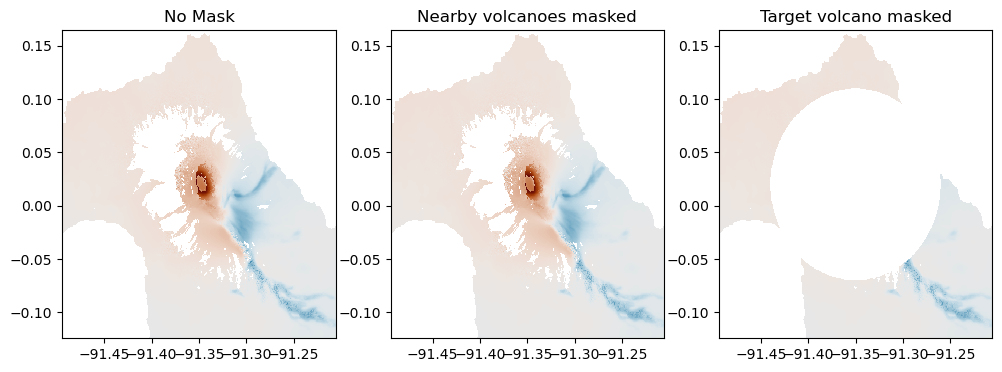

In [3]:
# Load GVP table:
GVP_Tab = '/work/xfc/vol7/user_cache/benirela/Other/GVP/GVP/GVP_Volcano_List_Holocene.xlsx'
GVP = pd.read_excel(GVP_Tab)

# Get volc name
VolcName = EndPath.split('/')[0]
VolcName = VolcName.replace('_', ' ')
#matches = GVP['Volcano Name'].str.contains(VolcName, case=False, na=False)
matches = GVP[GVP.iloc[:,1] == VolcName]
found = (GVP.iloc[:, 1].astype(str) == VolcName).any()

if found:
    print("Target volcano location found: " + VolcName)
else:
    print("No volcano name matching " + VolcName + " found in GVP table.")

# Get volc lat and lon
volcLat = matches.iloc[0, 8]
volcLon = matches.iloc[0, 9]

# Convert lat lon to km for buffering
bufferTargetVolc = 10 # in km
bufferOtherVolcs = 5 # in km
km_per_deg_lat = 111.32
km_per_deg_lon = 111.32 * np.cos(np.radians(volcLat))

volc_xy = np.column_stack([
    volcLon * km_per_deg_lon,
    volcLat * km_per_deg_lat
])

# Convert image pixels to km coordinates
LL_xy = np.column_stack([
    (Lon.ravel() * km_per_deg_lon),
    (Lat.ravel() * km_per_deg_lat)
])

# Use KDTree to find pixels within buffer distance of volcano
LL_tree = cKDTree(LL_xy)
neighbors = LL_tree.query_ball_point(volc_xy, r=bufferTargetVolc)
mask = np.zeros(LOS.shape, dtype=bool)
for idx in neighbors:
    Row, Col = np.unravel_index(idx, (LOS.shape[0], LOS.shape[1]))
    mask[Row, Col, :] = True

LOS_ThisVolc = np.copy(LOS)
LOS_ThisVolc[mask] = np.nan

# Find other volcanoes within the LOS extent + Buffer distance
MaxLon = (np.max(LL_xy[:, 0]) + bufferOtherVolcs)/km_per_deg_lon
MinLon = (np.min(LL_xy[:, 0]) - bufferOtherVolcs)/km_per_deg_lon
MaxLat = (np.max(LL_xy[:, 1]) + bufferOtherVolcs)/km_per_deg_lat
MinLat = (np.min(LL_xy[:, 1]) - bufferOtherVolcs)/km_per_deg_lat

GVP.iloc[:, 8] = pd.to_numeric(GVP.iloc[:, 8], errors="coerce")
GVP.iloc[:, 9] = pd.to_numeric(GVP.iloc[:, 9], errors="coerce")

latStr = GVP.iloc[:, 8]
lonStr = GVP.iloc[:, 9]
name = GVP.iloc[:,1]

# Filter to nearby volcanoes except target
Frame_Volcs = GVP[
    (GVP.iloc[:, 8] >= MinLat) &
    (GVP.iloc[:, 8] <= MaxLat) &
    (GVP.iloc[:, 9] >= MinLon) &
    (GVP.iloc[:, 9] <= MaxLon) &
    (GVP.iloc[:, 1] != VolcName)
]

if not Frame_Volcs.empty:
    print("Nearby volcanoes found:")
    print(Frame_Volcs.iloc[:, 1])
    # Create mask based on nearby volcanoes
    nearVolc_xy = np.column_stack([
        Frame_Volcs.iloc[:, 9] * km_per_deg_lon,
        Frame_Volcs.iloc[:, 8] * km_per_deg_lat
    ])
    neighbors2 = LL_tree.query_ball_point(nearVolc_xy, r=bufferOtherVolcs)
    mask2 = np.zeros(LOS.shape, dtype=bool)
    for idx in neighbors2:
        Row, Col = np.unravel_index(idx, (LOS.shape[0], LOS.shape[1]))
        mask2[Row, Col, :] = True

    LOS_NeabyVolcs = np.copy(LOS)
    LOS_NeabyVolcs[mask2] = np.nan
else:
    print("No nearby volcanoes found")
    LOS_NeabyVolcs = np.copy(LOS)

# Visualise masks
fig, axs = plt.subplots(1,3, figsize=(12, 4))
pcm = axs[0].pcolormesh(
    Lon,
    Lat,
    CumDisp,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
axs[0].set_title("No Mask")

pcm = axs[1].pcolormesh(
    Lon,
    Lat,
    LOS_NeabyVolcs[:, :, -1],
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
axs[1].set_title("Nearby volcanoes masked")

pcm = axs[2].pcolormesh(
    Lon,
    Lat,
    LOS_ThisVolc[:, :, -1],
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
axs[2].set_title("Target volcano masked")

In [4]:
# Define SNR function
def get_SNR(fullData, maskData, binWidth):
    maxD = np.nanmax(np.abs(fullData))
    # Plot histogram of temporal noise across each step outside the target volcano mask
    temporal_noise = np.nanstd(maskData, axis=2)
    temporal_noise = temporal_noise.flatten()
    temporal_noise = temporal_noise[~np.isnan(temporal_noise)]

    # Plot histogram of temporal noise
    binEdges = np.arange(-1,1,binWidth)
    counts, edges = np.histogram(temporal_noise, bins=binEdges)

    # Get bin with maximum count
    edge_max1 = edges[np.argmax(counts)]
    edge_max2 = edge_max1 + binWidth

    # Get mean of those in max bin
    Noise = np.mean(temporal_noise[(temporal_noise >= edge_max1) & (temporal_noise < edge_max2)])
    SNR = maxD/Noise
    return SNR, maxD, Noise, counts, edges, temporal_noise

In [5]:
binW = 0.001 # Bin width in meters (1 mm)
SNR, max_disp_all, Noise, counts, edges, temporal_noise = get_SNR(LOS,LOS_ThisVolc,binW)

print('Temporal noise: ' + str(round(Noise*100, 2)) + ' cm')
print('Max. Signal: ' + str(round(max_disp_all*100, 2)) + ' cm')
print('Signal-to-noise ratio: ' + str(round(SNR, 2)))
FullSNR = SNR

Temporal noise: 0.75 cm
Max. Signal: 61.58 cm
Signal-to-noise ratio: 81.87


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [6]:
SNRThresh = 3
SNRThresh_maybe = 2
T_winsize = 1 # Timeseries window size in years
if SNR > SNRThresh:
    print("SNR is greater than " + str(SNRThresh) + ", looking for signals")
    
    # Get timeseries indexes to query
    yrs = days_ / 365.25
    TS_Len = yrs[-1]
    yrsQ = np.arange(T_winsize,np.ceil(TS_Len),T_winsize)
    
    idxYrs = np.empty((len(yrsQ),1))
    idxYrs.fill(np.nan)
    for i , j in enumerate(yrsQ):
        idxYrs[i] = np.argmin(abs(yrs-j))
    idxYrs = idxYrs.astype(int).flatten()

    # Calculate SNR at every T_winsize in the dataset and index of biggest point
    Set_SNR = np.empty((len(yrsQ),1))
    Set_SNR.fill(np.nan)
    Set_maxD = Set_SNR.copy()
    Set_Noise = Set_SNR.copy()
    Set_SNR_Inc = Set_SNR.copy()
    Set_maxD_Inc = Set_SNR.copy()
    Set_Noise_Inc = Set_SNR.copy()
    RowIdx = Set_SNR.copy()
    ColIdx = Set_SNR.copy()
    TimeIdx = Set_SNR.copy()
    RowIdxInc = Set_SNR.copy()
    ColIdxInc = Set_SNR.copy()
    TimeIdxInc = Set_SNR.copy()
    StartIdx = Set_SNR.copy()
    StartYr = Set_SNR.copy()
    EndYr = Set_SNR.copy()

    for i in range(len(yrsQ)):
        if i==0:
            # Extract cumulative disp. during timeperiod X-Y
            Set_CumDisp = LOS[:,:,0:idxYrs[i]]
            Set_CumDispMask = LOS_ThisVolc[:,:,0:idxYrs[i]]

            Set_IncDisp = Set_CumDisp.copy()
            Set_IncDispMask = Set_CumDispMask.copy()

            StartIdx[i] = 0
        else:
            # Extract cumulative disp. during timeperiod X-Y
            Set_CumDisp = LOS[:,:,idxYrs[i-1]:idxYrs[i]]
            Set_CumDispMask = LOS_ThisVolc[:,:,idxYrs[i-1]:idxYrs[i]]

            # Extract stepwise disp. during timeperiod X-Y
            Set_IncDisp = LOS[:,:,idxYrs[i-1]:idxYrs[i]] - LOS[:,:,idxYrs[i-1]][:, :, None]
            Set_IncDispMask = LOS_ThisVolc[:,:,idxYrs[i-1]:idxYrs[i]] - LOS_ThisVolc[:,:,idxYrs[i-1]][:, :, None]

            StartIdx[i] = idxYrs[i-1]

        # Get spatial and temporal location of highest displacement during the timeperiod
        RowIdx[i], ColIdx[i], TimeIdx[i] = np.unravel_index(np.nanargmax(np.abs(Set_CumDisp)), Set_CumDisp.shape)
        RowIdxInc[i], ColIdxInc[i], TimeIdxInc[i] = np.unravel_index(np.nanargmax(np.abs(Set_IncDisp)), Set_IncDisp.shape)
        TimeIdx[i] = TimeIdx[i] + StartIdx[i]
        TimeIdxInc[i] = TimeIdxInc[i] + StartIdx[i]
        StartYr[i] = i-1
        EndYr[i] = i
        # Get SNR
        Set_SNR[i], Set_maxD[i], Set_Noise[i], _, _, _ = get_SNR(Set_CumDisp,Set_CumDispMask,binW)
        Set_SNR_Inc[i], Set_maxD_Inc[i], Set_Noise_Inc[i], _, _, _ = get_SNR(Set_IncDisp,Set_IncDispMask,binW)
        
        # if SNR(i)<SNRThresh:
        #     if i==1:
        #         Set_CumDisp = LOS[:,:,1:idx(i)]
        #         Set_CumDispMask = LOS_ThisVolc[:,:,1:idx(i)]
        #     else:
        #         Set_CumDisp = LOS[:,:,idx(i-1):idx(i)]
        #         Set_CumDispMask = LOS_ThisVolc[:,:,1:idx(i)]

    
elif SNR > SNRThresh_maybe:
    print("SNR is greater than " + str(SNRThresh_maybe) + ", but not greater than " + str(SNRThresh) + ", may be looking for signals")

else:
    print("SNR is less than or equal to " + str(SNRThresh_maybe) + ", likely no signals above noise level")


SNR is greater than 3, looking for signals


Text(0.5, 0.98, 'Labelled timeperiods above SNR threshold')

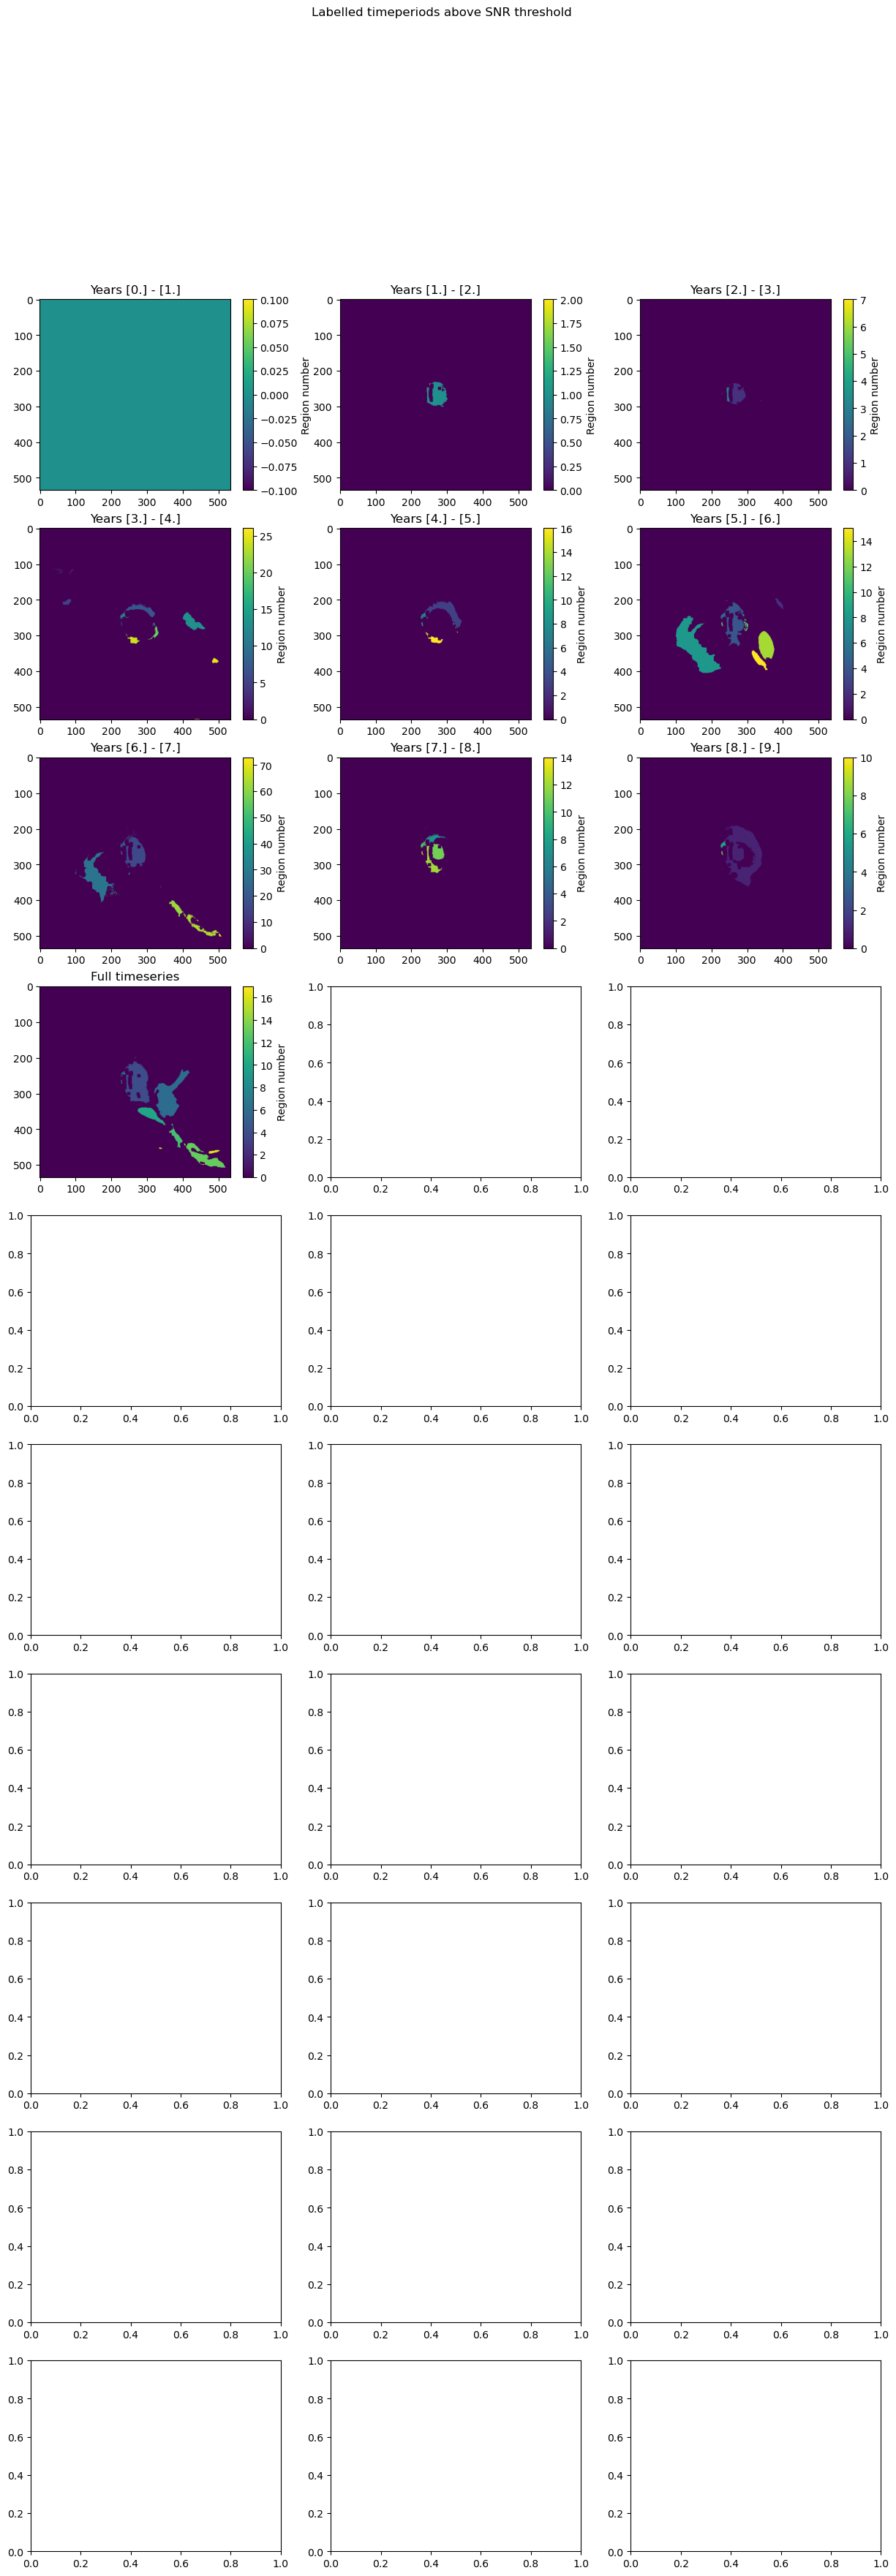

In [12]:
# Plot outputs of SNR tests
SNRThresh2 = 5
numCols = 3
numRows = np.ceil(len(yrsQ)+1/numCols).astype(int)
fig, axs = plt.subplots(numRows,numCols, figsize=(15, 40))

TimeIdxInc = TimeIdxInc.astype(int).flatten()
RowIdxInc = RowIdxInc.astype(int).flatten()
ColIdxInc = ColIdxInc.astype(int).flatten()
StartIdx = StartIdx.astype(int).flatten()

nplots = len(yrsQ) + 1  # +1 for full timeseries
total_slots = numRows * numCols

Disp_Steps = np.empty([LOS.shape[0],LOS.shape[1],len(yrsQ)])

for k in range(min(nplots, total_slots)):

    i, j = divmod(k, numCols)

    # Choose data
    if k == len(yrsQ):
        Disp = CumDisp.copy()
        title = "Full timeseries"
        #x = Lon[RowIdxInc, ColIdxInc]
        #y = Lat[RowIdxInc, ColIdxInc]
    else:
        Disp = LOS[:, :, TimeIdxInc[k]] - LOS[:,:, StartIdx[k]]
        title = f"Years {StartYr[k]+1} - {EndYr[k]+1}"
        #x = Lon[RowIdxInc[k], ColIdxInc[k]]
        #y = Lat[RowIdxInc[k], ColIdxInc[k]]

        Disp_Steps[:,:,k] = Disp

    SNR_map = np.abs(Disp) / Noise
    SNR_Mask = SNR_map > SNRThresh2

    sigma = 1
    Disp_Smooth = filters.gaussian(Disp, sigma=sigma)
    Img = (np.abs(Disp_Smooth)/np.nanmax(np.abs(Disp_Smooth)))*255
    Img = np.nan_to_num(Img, False, 0)

    Img_Thresh = filters.threshold_otsu(Img)
    binary = Img > Img_Thresh
    binary = binary * SNR_Mask

    Labels = measure.label(binary,connectivity=2)
    Img = axs[i,j].imshow(Labels)
    axs[i, j].set_title(title)
    cbar = plt.colorbar(Img,ax=axs[i,j])
    cbar.set_label("Region number")

plt.suptitle("Labelled timeperiods above SNR threshold")